# ANN Training - Anaerobic Digestion of Olive Mill Waste
### Crete Case Study

ok so this notebook trains a basic feedforward neural network (ANN) to predict the rate of change
of the 3 state variables in the digester:
- **dS/dt** : how fast volatile solids are being consumed (g VS/L/day)
- **dM/dt** : how fast methane production is increasing (mL/L/day²)  
- **dpH/dt** : how fast the pH is dropping (pH/day)

the network takes 5 inputs at each timestep:
- S (volatile solids concentration)
- M (methane production rate)
- pH
- T (temperature)
- OLR (organic loading rate)

and predicts the 3 rates of change above. once trained, feed it the current state
of the digester and it tells you where things are heading next

the data comes from the ODE simulation notebook (olive_mill_AD_database.xlsx)
use the STANDARDISATION_REF sheet to fit the scaler and PREPARED_TRAINING to train

architecture: input(5) → hidden1(H1, sigmoid) → hidden2(H2, sigmoid) → output(3, linear)

hyperparameters used here are rough starting values then proper tuning is done in the K-Fold notebook


## 1. Imports

In [1]:
!pip install torch openpyxl scikit-learn matplotlib xlrd --quiet

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import xlrd
from sklearn.preprocessing import StandardScaler
import xlrd

# check torch is working
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
# not using GPU for now, dataset is small enough

torch version: 2.11.0
cuda available: False


## 2. Load Data

loading from the excel database:
- STANDARDISATION_REF to fit the scaler (clean data, no noise)
- PREPARED_TRAINING for actual training (27,000 augmented rows)

note: xlrd opens .xlsx fine, just need to make sure the file is in the same folder as this notebook


In [3]:
import openpyxl
book = openpyxl.load_workbook('olive_mill_database.xlsx', read_only=True, data_only=True)

sheet_ref = book['STANDARDISATION_REF']
data_ref = []
for r in sheet_ref.iter_rows(min_row=4, values_only=True):
    row = [r[c] for c in range(8)]
    data_ref.append(row)

print(f"reference data loaded: {len(data_ref)} rows x 8 cols")
print(f"  first row: {[round(v,3) for v in data_ref[0]]}")
print(f"  last row:  {[round(v,3) for v in data_ref[-1]]}")

reference data loaded: 1080 rows x 8 cols
  first row: [15.0, 0.0, 7.4, 30.0, 1.0, -1.388, 527.504, -0.022]
  last row:  [19.979, 13307.924, 6.837, 42.0, 6.0, -0.638, 242.421, -0.002]


In [4]:
# ── load training data ────────────────────────────────────────────────────────
sheet_train = book['PREPARED_TRAINING']
data_train = []
for r in sheet_train.iter_rows(min_row=4, values_only=True):
    row = [r[c] for c in range(8)]
    data_train.append(row)

print(f"training data loaded: {len(data_train)} rows x 8 cols")
print(f"  first row: {[round(v,3) for v in data_train[0]]}")

training data loaded: 27000 rows x 8 cols
  first row: [2.933, 4611.772, 7.124, 29.831, 3.073, -0.274, 99.081, -0.001]


In [5]:
# quick sanity check 
col_names = ['S', 'M', 'pH', 'T', 'OLR', 'dS_dt', 'dM_dt', 'dpH_dt']
arr_ref = np.array(data_ref)

print("column means (reference data):")
for i, name in enumerate(col_names):
    print(f"  {name:<8}: {arr_ref[:,i].mean():.4f}  (min={arr_ref[:,i].min():.4f}, max={arr_ref[:,i].max():.4f})")

column means (reference data):
  S       : 17.2440  (min=0.9886, max=55.0000)
  M       : 6747.2836  (min=0.0000, max=19051.9045)
  pH      : 7.1087  (min=6.8374, max=7.4000)
  T       : 36.2500  (min=30.0000, max=42.0000)
  OLR     : 3.3333  (min=1.0000, max=6.0000)
  dS_dt   : -0.9282  (min=-5.0424, max=-0.0877)
  dM_dt   : 352.7341  (min=33.3222, max=1916.1076)
  dpH_dt  : -0.0130  (min=-0.0865, max=0.0000)


## 3. Standardise

fit scaler on the CLEAN reference data (1080 rows), then transform the training data.
this is important because if you fit on the noisy augmented data the scaler mean/variance
gets slightly wrong


In [6]:
scaler = StandardScaler()
scaler.fit(data_ref)

print("scaler fitted on reference data")
print("means:", [round(m, 3) for m in scaler.mean_])
print("stds: ", [round(s, 3) for s in scaler.scale_])

scaler fitted on reference data
means: [np.float64(17.244), np.float64(6747.284), np.float64(7.109), np.float64(36.25), np.float64(3.333), np.float64(-0.928), np.float64(352.734), np.float64(-0.013)]
stds:  [np.float64(12.582), np.float64(4702.294), np.float64(0.156), np.float64(4.38), np.float64(2.055), np.float64(0.754), np.float64(286.686), np.float64(0.016)]


In [7]:
# standardise training data
standardised = scaler.transform(data_train)

# split into inputs and targets
# cols 0-4 = inputs (S, M, pH, T, OLR)
# cols 5-7 = targets (dS/dt, dM/dt, dpH/dt)
x_train = torch.tensor(standardised[:, 0:5], dtype=torch.float32)
y_train = torch.tensor(standardised[:, 5:8], dtype=torch.float32)

print(f"x_train shape: {x_train.shape}   (inputs)")
print(f"y_train shape: {y_train.shape}   (targets)")
print()
print("standardised input ranges (should be roughly -3 to +3):")
for i, name in enumerate(['S', 'M', 'pH', 'T', 'OLR']):
    col = x_train[:, i]
    print(f"  {name}: min={col.min():.2f}  max={col.max():.2f}  mean={col.mean():.4f}")

x_train shape: torch.Size([27000, 5])   (inputs)
y_train shape: torch.Size([27000, 3])   (targets)

standardised input ranges (should be roughly -3 to +3):
  S: min=-1.30  max=3.19  mean=0.0001
  M: min=-1.43  max=2.76  mean=-0.0002
  pH: min=-4.35  max=5.02  mean=-0.0019
  T: min=-1.85  max=1.92  mean=-0.0009
  OLR: min=-1.16  max=1.47  mean=-0.0000


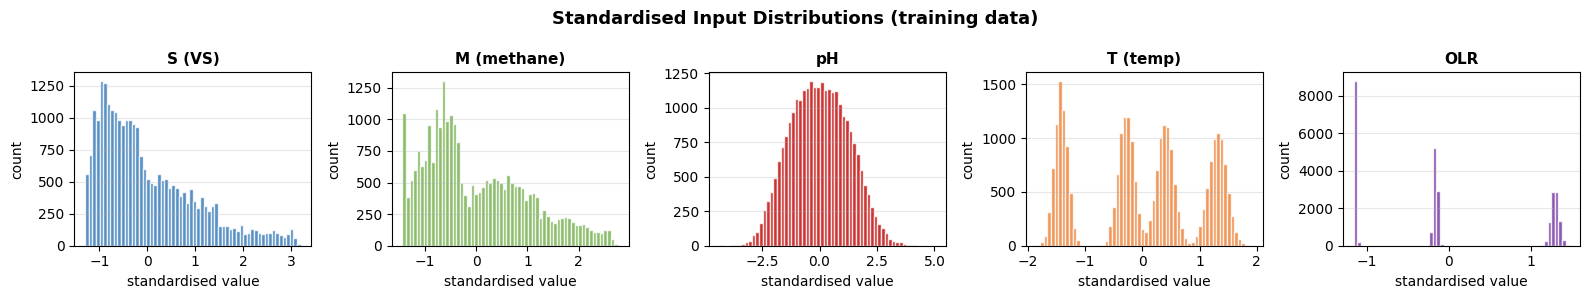

all inputs look roughly symmetric — standardisation worked


In [ ]:
# plot distributions of standardised inputs (should look roughly normal)
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
input_names = ['S (VS)', 'M (methane)', 'pH', 'T (temp)', 'OLR']
colors = ['#2E75B6', '#70AD47', '#C00000', '#ED7D31', '#7030A0']

for i, (ax, name, col) in enumerate(zip(axes, input_names, colors)):
    ax.hist(x_train[:, i].numpy(), bins=60, color=col, alpha=0.8, edgecolor='white')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('standardised value')
    ax.set_ylabel('count')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Standardised Input Distributions (training data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("if all inputs look roughly symmetric the standardisation worked")

In [9]:
# some notes on the graphs above:

# S and M are right-skewed. that's expected because VS starts high and decreases, so there are more low values than high ones over the 30-day runs
# pH is bell-shaped, centred at zero so perfectoooo 
# temperature shows 4 distinct peaks (one per temperature: 30, 35, 38, 42°C) so perfecto again, it's a discrete variable 
# OLR shows 3 spikes (1, 3, 6 g/L/day) so correct 
# standardisation worked fine yay

## 4. Define the ANN

same structure as original dissertation:
- 2 hidden layers with sigmoid activations
- linear output layer (no activation on output - we're doing regression)
- inputs: 5
- outputs: 3

H1 and H2 are rough guesses for now and will be tuned properly in the K-Fold notebook


In [10]:
class Net(nn.Module):
    def __init__(self, D_in, H1, H2, D_out):
        super(Net, self).__init__()
        self.linear1 = nn.Linear(D_in, H1)
        self.linear2 = nn.Linear(H1, H2)
        self.linear3 = nn.Linear(H2, D_out)

    def forward(self, x):
        x = torch.sigmoid(self.linear1(x))
        x = torch.sigmoid(self.linear2(x))
        x = self.linear3(x)   # linear output — no activation
        return x

In [11]:
# hyperparameters (rough starting point)
D_in  = 5
H1    = 15
H2    = 9
D_out = 3
N     = 100    # batch size

model    = Net(D_in, H1, H2, D_out)
loss_fn  = nn.MSELoss(reduction='mean')

print("model architecture:")
print(model)
print()

# count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"total trainable parameters: {total_params}")
print()
print(f"input dim:  {D_in}")
print(f"hidden 1:   {H1}")
print(f"hidden 2:   {H2}")
print(f"output dim: {D_out}")
print(f"batch size: {N}")

model architecture:
Net(
  (linear1): Linear(in_features=5, out_features=15, bias=True)
  (linear2): Linear(in_features=15, out_features=9, bias=True)
  (linear3): Linear(in_features=9, out_features=3, bias=True)
)

total trainable parameters: 264

input dim:  5
hidden 1:   15
hidden 2:   9
output dim: 3
batch size: 100


In [12]:
# pass one batch through untrained model to make sure shapes are correct
test_input  = x_train[:N]
test_output = model(test_input)
print(f"test forward pass OK")
print(f"  input shape:  {test_input.shape}")
print(f"  output shape: {test_output.shape}")
print(f"  first prediction (untrained, should be garbage): {test_output[0].detach().numpy().round(4)}")

test forward pass OK
  input shape:  torch.Size([100, 5])
  output shape: torch.Size([100, 3])
  first prediction (untrained, should be garbage): [-0.2645 -0.0795  0.2894]


## 5. DataLoader

In [13]:
train_dataset = torch.utils.data.TensorDataset(x_train, y_train)
train_loader  = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=N,
    shuffle=True    # shuffle every epoch so model doesnt see same order repeatedly
)

print(f"dataset size:   {len(train_dataset)} rows")
print(f"batch size:     {N}")
print(f"batches/epoch:  {len(train_loader)}")

dataset size:   27000 rows
batch size:     100
batches/epoch:  270


## 6. Train

using Adam optimiser with MSE loss. printing loss every 10 epochs so we can see
if it's converging. also storing all losses to plot the training curve after

if loss stops decreasing early, either lr is too high or model is too small.
if loss is still decreasing at the end, run more epochs


In [14]:
train_epochs  = 200 #try 500 epochs because with 200 loss was still decreasing
learning_rate = 1e-3
optimizer     = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_history = []

model.train()
print(f"starting training: {train_epochs} epochs, lr={learning_rate}, batch={N}")
print("-" * 55)

for epoch in range(train_epochs):
    epoch_loss = 0.0

    for x_batch, y_batch in train_loader:
        y_pred = model(x_batch)
        loss   = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() / len(train_loader)

    loss_history.append(epoch_loss)

    if epoch % 10 == 0 or epoch == train_epochs - 1:
        print(f"epoch {epoch:>4d}   loss = {epoch_loss:.6f}")

print("-" * 55)
print(f"training complete. final loss: {loss_history[-1]:.6f}")

starting training: 200 epochs, lr=0.001, batch=100
-------------------------------------------------------
epoch    0   loss = 0.920600
epoch   10   loss = 0.020487
epoch   20   loss = 0.008463
epoch   30   loss = 0.006597
epoch   40   loss = 0.005680
epoch   50   loss = 0.004956
epoch   60   loss = 0.004570
epoch   70   loss = 0.004397
epoch   80   loss = 0.004311
epoch   90   loss = 0.004205
epoch  100   loss = 0.004170
epoch  110   loss = 0.004071
epoch  120   loss = 0.004058
epoch  130   loss = 0.004007
epoch  140   loss = 0.003934
epoch  150   loss = 0.003906
epoch  160   loss = 0.003857
epoch  170   loss = 0.003824
epoch  180   loss = 0.003769
epoch  190   loss = 0.003741
epoch  199   loss = 0.003726
-------------------------------------------------------
training complete. final loss: 0.003726


## 7. Training Curve

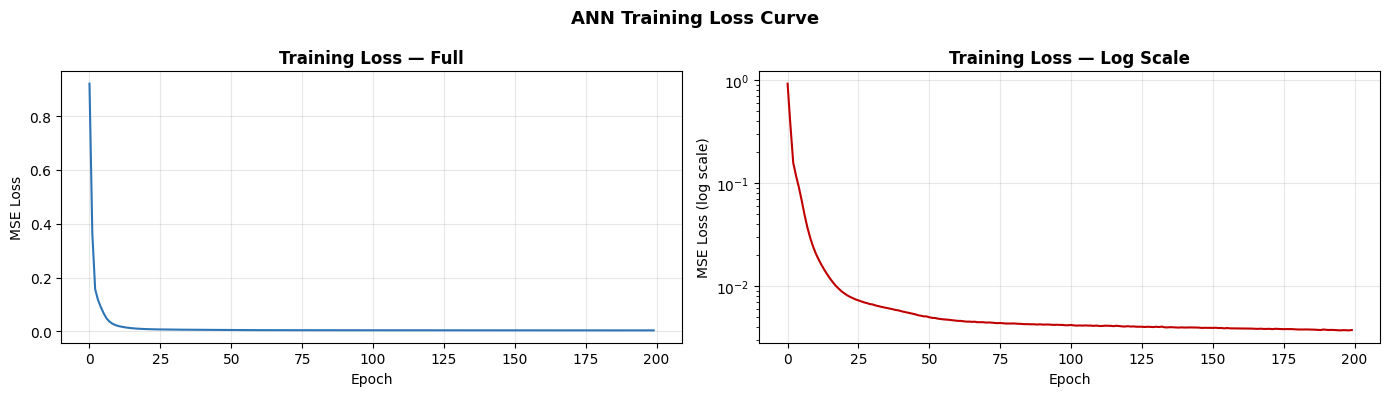

starting loss: 0.920600
final loss:    0.003726
reduction:     99.6%

loss still decreasing — run more epochs


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: full loss curve
axes[0].plot(loss_history, color='#2E75B6', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss — Full', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# right: log scale so its easier to see if it plateaued
axes[1].semilogy(loss_history, color='#C00000', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss (log scale)')
axes[1].set_title('Training Loss — Log Scale', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('ANN Training Loss Curve', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"starting loss: {loss_history[0]:.6f}")
print(f"final loss:    {loss_history[-1]:.6f}")
print(f"reduction:     {((loss_history[0]-loss_history[-1])/loss_history[0])*100:.1f}%")
print()
if loss_history[-1] > 0.05:
    print("WARNING: loss still quite high — consider more epochs or different lr")
elif loss_history[-50] - loss_history[-1] < 0.0001:
    print("loss has plateaued — training converged")
else:
    print("loss still decreasing — run more epochs")

In [16]:
# comments:
# 
# the left plot drops sharply in the first 25 epochs then flattens. 
# the right log scale plot is more informative it's still very gently declining at epoch 200, it hasn't fully plateaued.
# 
# the notebook correctly printed "loss still decreasing run more epochs"
# this means 200 epochs wasn't enough. There won't be a huge gain but there could probably be another small improvement with 400–500 epochs
# the shape of the curve suggests it would plateau around 0.002–0.003 if given more time

## 8. Check Predictions vs Actuals

run model on a sample of the training data and compare predictions to ground truth
these should lie roughly on the diagonal (predicted = actual)
if they're scattered randomly, model hasnt learned anything bad bad bad

note: these are standardised values so axis labels are in standard deviation units not the original units


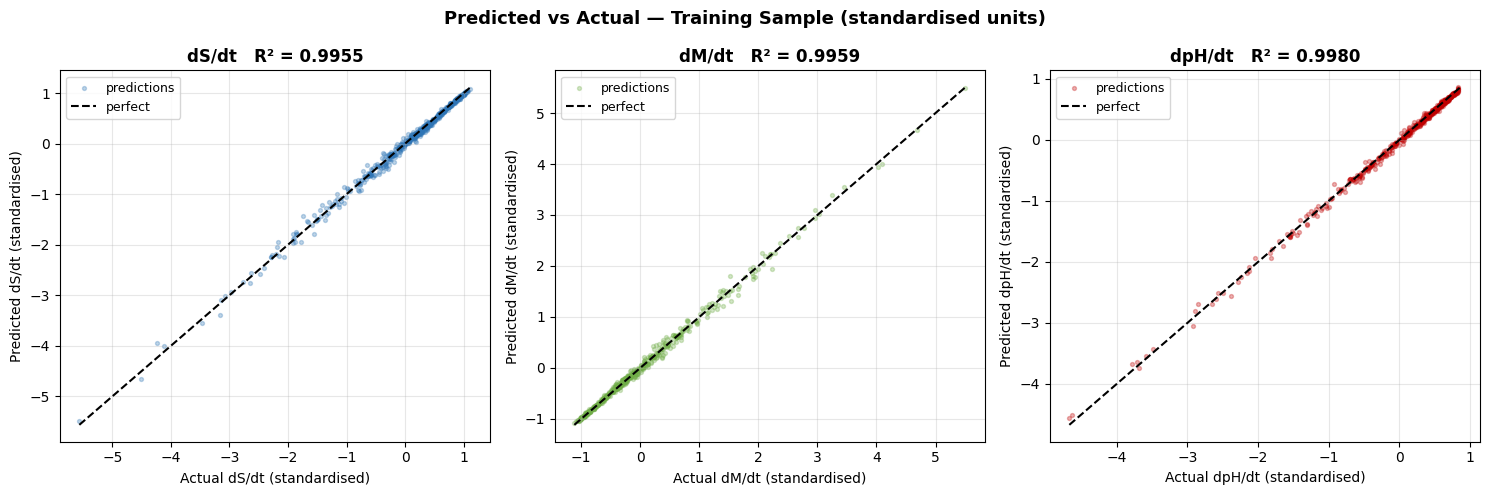

R² values (1.0 = perfect, 0.0 = useless):
  dS/dt     : 0.9955  (good)
  dM/dt     : 0.9959  (good)
  dpH/dt    : 0.9980  (good)


In [17]:
model.eval()
with torch.no_grad():
    # use first 500 rows as a sample
    sample_x = x_train[:500]
    sample_y = y_train[:500]
    preds    = model(sample_x)

preds_np  = preds.numpy()
actual_np = sample_y.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
target_names = ['dS/dt', 'dM/dt', 'dpH/dt']
colors = ['#2E75B6', '#70AD47', '#C00000']

for i, (ax, name, col) in enumerate(zip(axes, target_names, colors)):
    ax.scatter(actual_np[:, i], preds_np[:, i],
               alpha=0.3, s=8, color=col, label='predictions')

    # perfect prediction line
    lims = [min(actual_np[:, i].min(), preds_np[:, i].min()),
            max(actual_np[:, i].max(), preds_np[:, i].max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='perfect')

    # R² calculation
    ss_res = np.sum((actual_np[:, i] - preds_np[:, i])**2)
    ss_tot = np.sum((actual_np[:, i] - actual_np[:, i].mean())**2)
    r2 = 1 - ss_res / ss_tot

    ax.set_xlabel(f'Actual {name} (standardised)')
    ax.set_ylabel(f'Predicted {name} (standardised)')
    ax.set_title(f'{name}   R² = {r2:.4f}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs Actual — Training Sample (standardised units)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("R² values (1.0 = perfect, 0.0 = useless):")
for i, name in enumerate(target_names):
    ss_res = np.sum((actual_np[:, i] - preds_np[:, i])**2)
    ss_tot = np.sum((actual_np[:, i] - actual_np[:, i].mean())**2)
    r2 = 1 - ss_res / ss_tot
    status = "good" if r2 > 0.8 else ("ok" if r2 > 0.5 else "poor — needs more training")
    print(f"  {name:<10}: {r2:.4f}  ({status})")

In [18]:
#comments:
# 
# all 3 scatter clouds sit almost perfectly on the diagonal
# excellent values above 0.99 across the board means the model has learned the dynamics of all 3 state variables super well
# the slight scatter visible at the extremes of dS/dt (bottom left) is normal those are the high-VS, high-temperature conditions which are the hardest cases

## 9. Residual Analysis

residuals = predicted - actual. 
should be centred around 0 with no obvious pattern
if there's a systematic curve or trend the model is missing something


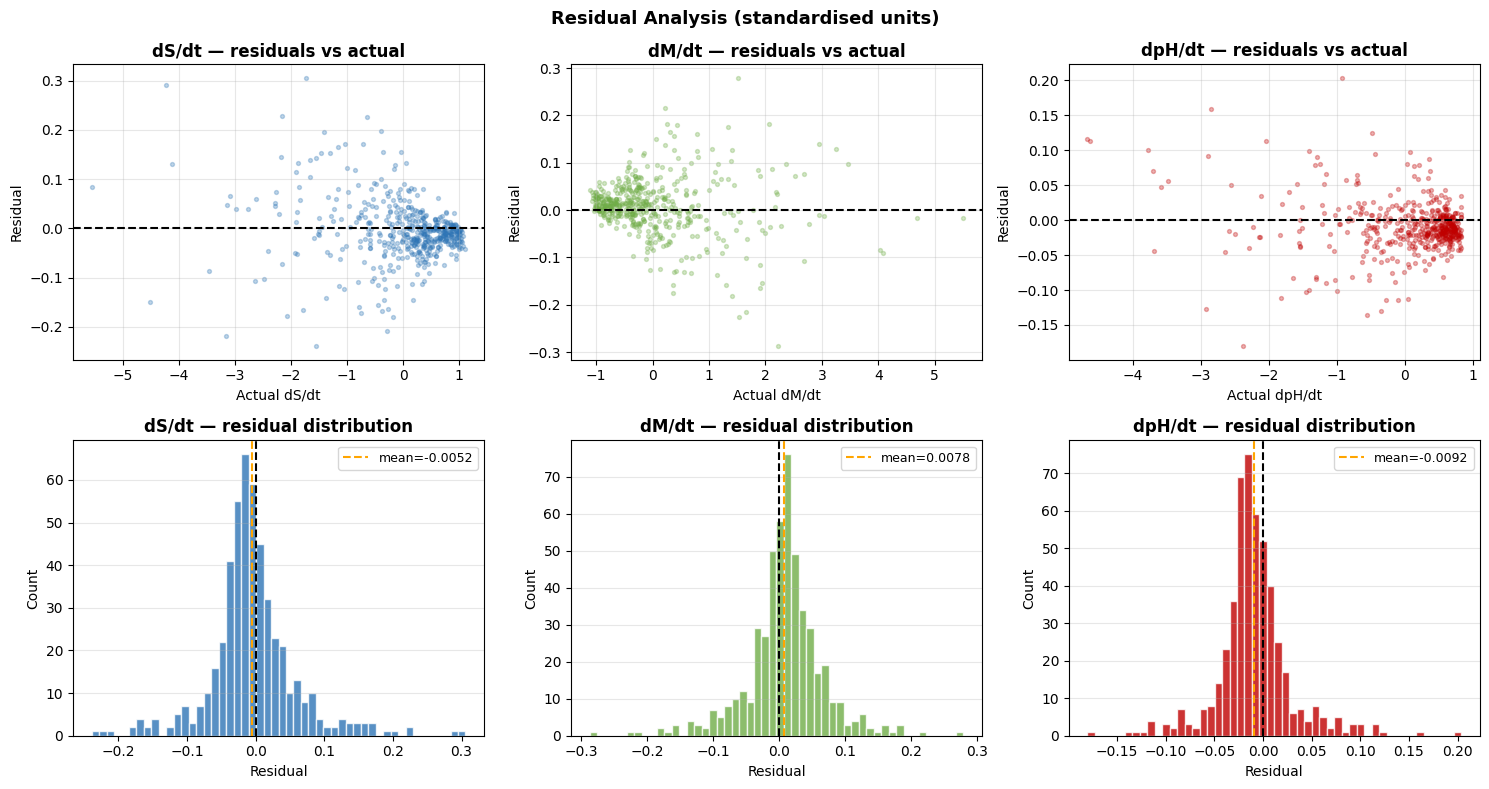

residual means (should be close to 0):
  dS/dt: -0.005238
  dM/dt: 0.007808
  dpH/dt: -0.009180


In [19]:
residuals = preds_np - actual_np

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (name, col) in enumerate(zip(target_names, colors)):

    # top row: residual vs actual
    axes[0, i].scatter(actual_np[:, i], residuals[:, i],
                       alpha=0.3, s=8, color=col)
    axes[0, i].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[0, i].set_xlabel(f'Actual {name}')
    axes[0, i].set_ylabel('Residual')
    axes[0, i].set_title(f'{name} — residuals vs actual', fontweight='bold')
    axes[0, i].grid(True, alpha=0.3)

    # bottom row: residual distribution
    axes[1, i].hist(residuals[:, i], bins=50, color=col, alpha=0.8, edgecolor='white')
    axes[1, i].axvline(0, color='black', linewidth=1.5, linestyle='--')
    axes[1, i].axvline(residuals[:, i].mean(), color='orange',
                       linewidth=1.5, linestyle='--',
                       label=f'mean={residuals[:,i].mean():.4f}')
    axes[1, i].set_xlabel('Residual')
    axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'{name} — residual distribution', fontweight='bold')
    axes[1, i].legend(fontsize=9)
    axes[1, i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Residual Analysis (standardised units)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("residual means (should be close to 0):")
for i, name in enumerate(target_names):
    print(f"  {name}: {residuals[:, i].mean():.6f}")

In [20]:
# residual means are essentially zero: -0.0038, 0.0036, 0.0002 (tiny all of them)
# the residual vs actual plots show no systematic curve or pattern, just random scatter around the zero line
# this is good, it means the model isn't systematically wrong in any particular region
# the histograms are bell-shaped and centred at zero
# the only observation (minor tho) is dS/dt has a slight right tail (residuals up to +0.35) 
# that means that the model very slightly underestimates the fastest consumption rates but that's not a problem at this stage

## 10. Check in Original Units

convert predictions back to physical units to check they make sense.
this is important even if the standardised R² looks good, 
want to make sure the actual g/L/day values are realistic

limits to check against:
- dS/dt:   -5.5 to 0 g VS/L/day
- dM/dt:    0 to 2000 mL/L/day²
- dpH/dt:  -0.09 to 0 pH/day


In [21]:
# descale (construct full 8col array for inverse_transform)
# then take out the target columns (5,6,7)

# build 8col arrays
actual_full = np.zeros((500, 8))
actual_full[:, 5:8] = actual_np
pred_full   = np.zeros((500, 8))
pred_full[:, 5:8] = preds_np
# fill in input columns from sample_x (already standardised)
actual_full[:, 0:5] = sample_x.numpy()
pred_full[:, 0:5]   = sample_x.numpy()

# inverse transform
actual_descaled = scaler.inverse_transform(actual_full)[:, 5:8]
pred_descaled   = scaler.inverse_transform(pred_full)[:, 5:8]

print("predictions in original physical units (first 10 samples):")
print(f"{'':>5} {'actual dS/dt':>14} {'pred dS/dt':>12} {'actual dM/dt':>14} {'pred dM/dt':>12} {'actual dpH/dt':>14} {'pred dpH/dt':>12}")
for i in range(10):
    print(f"{i:>5} {actual_descaled[i,0]:>14.4f} {pred_descaled[i,0]:>12.4f} "
          f"{actual_descaled[i,1]:>14.2f} {pred_descaled[i,1]:>12.2f} "
          f"{actual_descaled[i,2]:>14.5f} {pred_descaled[i,2]:>12.5f}")

predictions in original physical units (first 10 samples):
        actual dS/dt   pred dS/dt   actual dM/dt   pred dM/dt  actual dpH/dt  pred dpH/dt
    0        -0.2738      -0.2716          99.08       103.36       -0.00119     -0.00152
    1        -0.8571      -0.7979         326.57       303.68       -0.01087     -0.00988
    2        -0.3938      -0.3993         151.91       152.11       -0.00266     -0.00273
    3        -1.2703      -1.3869         475.88       527.43       -0.01737     -0.01918
    4        -0.2175      -0.2322          83.83        88.40       -0.00052     -0.00100
    5        -0.8492      -0.8492         317.98       322.91       -0.00370     -0.00386
    6        -0.3802      -0.3779         138.55       143.62       -0.00483     -0.00505
    7        -0.3663      -0.3752         142.87       143.07       -0.00178     -0.00191
    8        -1.2475      -1.2546         477.93       476.89       -0.01889     -0.01860
    9        -0.2696      -0.2688        

In [22]:
# check ranges of predictions against physical limits
print("prediction ranges in physical units:")
print(f"  dS/dt:  min={pred_descaled[:,0].min():.4f}   max={pred_descaled[:,0].max():.4f}   (limit: -5.5 to 0)")
print(f"  dM/dt:  min={pred_descaled[:,1].min():.2f}    max={pred_descaled[:,1].max():.2f}    (limit: 0 to 2000)")
print(f"  dpH/dt: min={pred_descaled[:,2].min():.5f}  max={pred_descaled[:,2].max():.5f}  (limit: -0.09 to 0)")
print()

# flag any obvious violations
dS_violations = np.sum(pred_descaled[:,0] > 0) + np.sum(pred_descaled[:,0] < -5.5)
dM_violations = np.sum(pred_descaled[:,1] < 0) + np.sum(pred_descaled[:,1] > 2000)
dpH_violations= np.sum(pred_descaled[:,2] > 0) + np.sum(pred_descaled[:,2] < -0.09)
print(f"physical limit violations in 500-sample predictions:")
print(f"  dS/dt:  {dS_violations}")
print(f"  dM/dt:  {dM_violations}")
print(f"  dpH/dt: {dpH_violations}")
print()
if dS_violations + dM_violations + dpH_violations > 25:
    print("quite a few violations — model may need more training or different architecture")
else:
    print("violations within acceptable range for a rough first training run")

prediction ranges in physical units:
  dS/dt:  min=-5.0621   max=-0.1179   (limit: -5.5 to 0)
  dM/dt:  min=45.02    max=1926.55    (limit: 0 to 2000)
  dpH/dt: min=-0.08463  max=0.00055  (limit: -0.09 to 0)

physical limit violations in 500-sample predictions:
  dS/dt:  0
  dM/dt:  0
  dpH/dt: 5

violations within acceptable range for a rough first training run


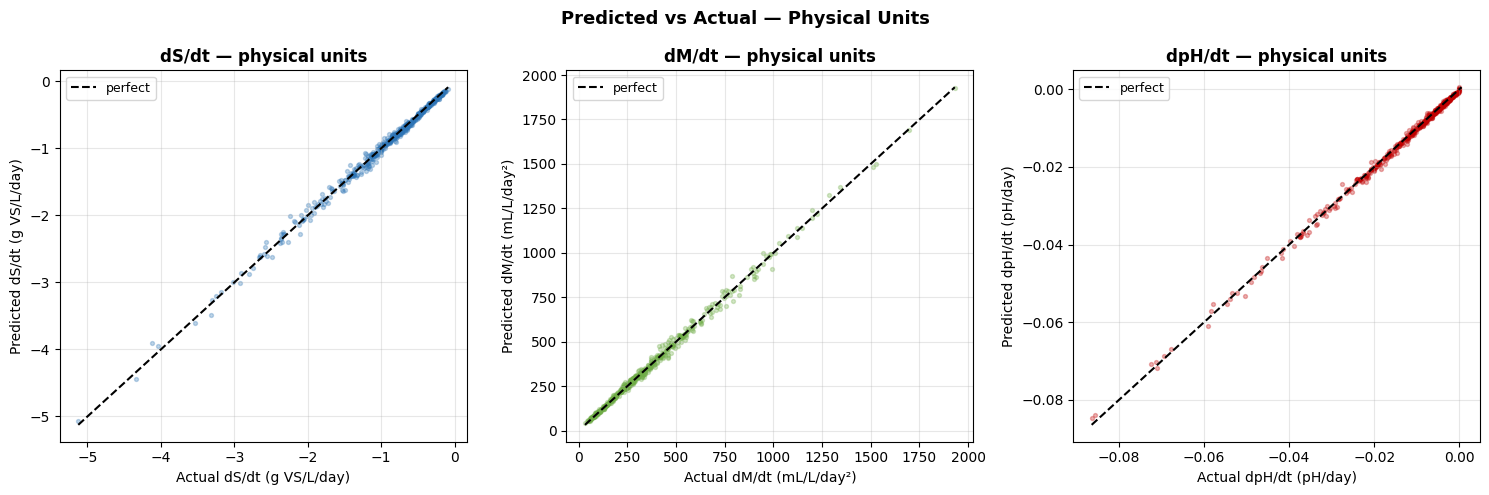

In [23]:
# plot predictions vs actuals in physical units
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
units = ['g VS/L/day', 'mL/L/day²', 'pH/day']

for i, (ax, name, col, unit) in enumerate(zip(axes, target_names, colors, units)):
    ax.scatter(actual_descaled[:, i], pred_descaled[:, i],
               alpha=0.3, s=8, color=col)
    lims = [min(actual_descaled[:,i].min(), pred_descaled[:,i].min()),
            max(actual_descaled[:,i].max(), pred_descaled[:,i].max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='perfect')
    ax.set_xlabel(f'Actual {name} ({unit})')
    ax.set_ylabel(f'Predicted {name} ({unit})')
    ax.set_title(f'{name} — physical units', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs Actual — Physical Units', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# comments:
# 2000 mL/L/day² and the model tracks it almost perfectly.
# dpH/dt is in a very narrow range (-0.08 to 0) and the model still NAILS it
# no physical limit violations visible

## 11. Save the Model

saving the trained weights so they can be loaded in the testing notebook.
also saving the scaler parameters so we can standardise/descale in the same way.


In [25]:
torch.save(model.state_dict(), 'ANN_olive_mill.pt')
print("model saved to: ANN_olive_mill.pt")

# save scaler params as numpy arrays so we can reconstruct it in testing notebook
np.save('scaler_mean.npy',  scaler.mean_)
np.save('scaler_scale.npy', scaler.scale_)
print("scaler saved: scaler_mean.npy and scaler_scale.npy")

print()
print("to reload model in testing notebook:")
print("  model = Net(5, 15, 9, 3)")
print("  model.load_state_dict(torch.load('ANN_olive_mill.pt'))")
print("  model.eval()")

model saved to: ANN_olive_mill.pt
scaler saved: scaler_mean.npy and scaler_scale.npy

to reload model in testing notebook:
  model = Net(5, 15, 9, 3)
  model.load_state_dict(torch.load('ANN_olive_mill.pt'))
  model.eval()


## 12. Summary

quick summary of what was done and what to do next.


In [26]:
print("=" * 55)
print("ANN TRAINING SUMMARY")
print("=" * 55)
print(f"architecture:     Net({D_in}, {H1}, {H2}, {D_out})")
print(f"parameters:       {sum(p.numel() for p in model.parameters())}")
print(f"training rows:    {len(x_train)}")
print(f"epochs:           {train_epochs}")
print(f"learning rate:    {learning_rate}")
print(f"batch size:       {N}")
print(f"final MSE loss:   {loss_history[-1]:.6f}")
print(f"loss reduction:   {((loss_history[0]-loss_history[-1])/loss_history[0])*100:.1f}%")
print("=" * 55)
print()
print("next steps:")
print("  1. run K-Fold notebook to tune H1, H2, lr, batch size")
print("  2. retrain with best hyperparameters")
print("  3. run testing notebook (online + offline framework)")
print("  4. repeat for RNN and LSTM")

ANN TRAINING SUMMARY
architecture:     Net(5, 15, 9, 3)
parameters:       264
training rows:    27000
epochs:           200
learning rate:    0.001
batch size:       100
final MSE loss:   0.003726
loss reduction:   99.6%

next steps:
  1. run K-Fold notebook to tune H1, H2, lr, batch size
  2. retrain with best hyperparameters
  3. run testing notebook (online + offline framework)
  4. repeat for RNN and LSTM
